   id_usuario            nombre                   correo      ciudad      rol  \
0           1  Jonathan Brandon       jonathan@gmail.com        Leon  usuario   
1           2  Adriana Michelle  sin_correo@ecocycle.com        Leon  usuario   
2           3          Salvador       salvador@gmail.com  Guanajuato  usuario   
3           4      Jose Osvaldo           jose@gmail.com        Leon  usuario   
4           5             Uriel          uriel@gmail.com       Silao  usuario   

   usuario_id  botellas_recicladas  puntos_acumulados  sesiones_realizadas  
0           1                    8                 80                    2  
1           2                    0                 30                    2  
2           3                   10                100                    1  
3           4                    4                 40                    1  
4           5                    7                 70                    1  
Vista previa del dataset:


,id_usuario,nombre,correo,ciudad,rol,usuario_id,botellas_recicladas,puntos_acumulados,sesiones_realizadas
0,1,Jonathan Brandon,jonathan@gmail.com,Leon,usuario,1,8,80,2
1,2,Adriana Michelle,sin_correo@ecocycle.com,Leon,usuario,2,0,30,2
2,3,Salvador,salvador@gmail.com,Guanajuato,usuario,3,10,100,1
3,4,Jose Osvaldo,jose@gmail.com,Leon,usuario,4,4,40,1
4,5,Uriel,uriel@gmail.com,Silao,usuario,5,7,70,1


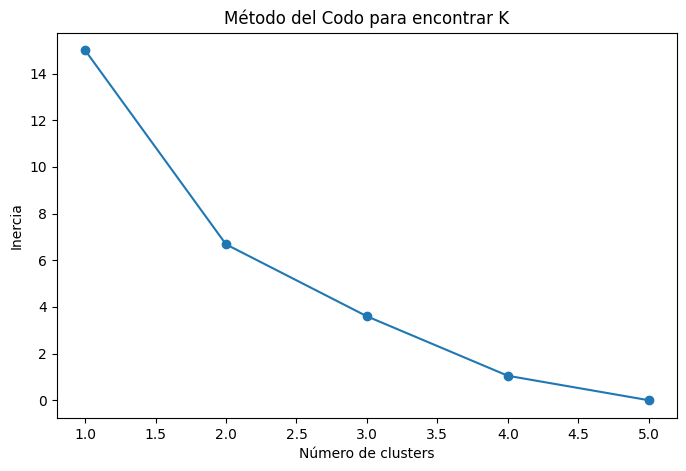

Clusters asignados:


,id_usuario,nombre,correo,ciudad,rol,usuario_id,botellas_recicladas,puntos_acumulados,sesiones_realizadas,cluster
0,1,Jonathan Brandon,jonathan@gmail.com,Leon,usuario,1,8,80,2,0
1,2,Adriana Michelle,sin_correo@ecocycle.com,Leon,usuario,2,0,30,2,1
2,3,Salvador,salvador@gmail.com,Guanajuato,usuario,3,10,100,1,0
3,4,Jose Osvaldo,jose@gmail.com,Leon,usuario,4,4,40,1,2
4,5,Uriel,uriel@gmail.com,Silao,usuario,5,7,70,1,2


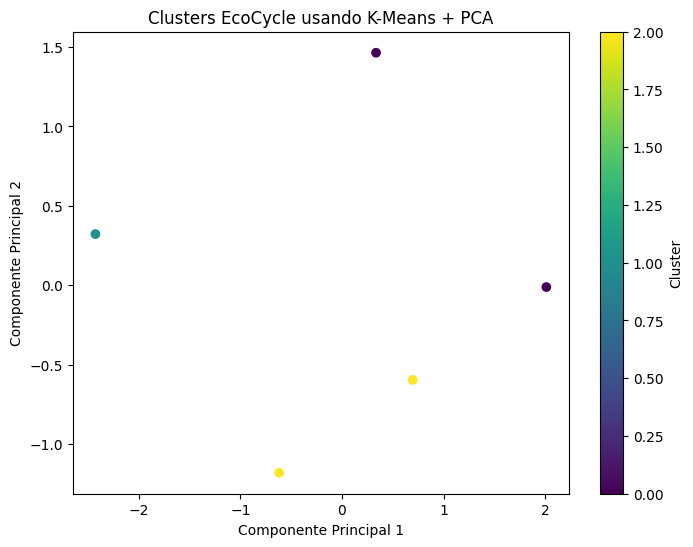

Modelo generado correctamente:
- K-Means para agrupación
- PCA para reducción de dimensionalidad
- Clusters creados: 3


In [5]:
# ==============================
# ECOCYCLE - KMEANS + PCA
# ==============================

# Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Carga de datos
usuarios = pd.read_csv("usuarios_limpios.csv")
sesiones = pd.read_csv("sesiones_limpias.csv")

# Agrupar sesiones por usuario
perfil_usuario = sesiones.groupby("usuario_id").agg({

    "botellas": "sum",
    "puntos": "sum",
    "id_sesion": "count"

}).reset_index()


# Renombrar columnas
perfil_usuario = perfil_usuario.rename(columns={
    "botellas": "botellas_recicladas",
    "puntos": "puntos_acumulados",
    "id_sesion": "sesiones_realizadas"
})

# Unir con usuarios
dataset_kmeans = usuarios.merge(
    perfil_usuario,
    left_on="id_usuario",
    right_on="usuario_id"
)

dataset_kmeans.fillna(0, inplace=True)
print(dataset_kmeans)

# Mostrar datos iniciales
print("Vista previa del dataset:")
display(dataset_kmeans.head())

# Se toman las variables más importantes del comportamiento del usuario
data = dataset_kmeans[[
    "botellas_recicladas",
    "puntos_acumulados",
    "sesiones_realizadas"
]]

# Normalizacion de datos
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Metodo del codo
inercia = []

for k in range(1, len(data_scaled)+1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inercia.append(kmeans.inertia_)

# Gráfica del método del codo
plt.figure(figsize=(8,5))

plt.plot(range(1, len(inercia)+1),inercia,marker='o')
plt.title("Método del Codo para encontrar K")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()


# Se define el número de clusters (puedes cambiarlo según la gráfica)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(data_scaled)

# Se agregan los clusters al dataset
dataset_kmeans["cluster"] = clusters

print("Clusters asignados:")
display(dataset_kmeans.head())


# Reduccion de dimensionalidad
pca = PCA(n_components=2)
componentes = pca.fit_transform(data_scaled)

dataset_kmeans["PCA1"] = componentes[:, 0]
dataset_kmeans["PCA2"] = componentes[:, 1]

# Visualizacion final
plt.figure(figsize=(8,6))
plt.scatter(
    dataset_kmeans["PCA1"],
    dataset_kmeans["PCA2"],
    c=dataset_kmeans["cluster"],
    cmap="viridis"
)

plt.title("Clusters EcoCycle usando K-Means + PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label="Cluster")
plt.show()

print("Modelo generado correctamente:")
print("- K-Means para agrupación")
print("- PCA para reducción de dimensionalidad")
print("- Clusters creados:", dataset_kmeans["cluster"].nunique())